# Examples

In the following, we demonstrate several `sbijax` methods using the complex "Simple Liklelihood Complex Posterior" model.

In [1]:
import jax
import optax
import os
import sbijax
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt

from matplotlib.ticker import AutoLocator, MaxNLocator
from jax import numpy as jnp, random as jr
from tensorflow_probability.substrates.jax import distributions as tfd

We remove some warnings that TFP is emitting, when using 64-bit arithmetic instead of 32-bit.

In [2]:
import warnings
warnings.filterwarnings("ignore")

We implement a custom function to visualize posterior pairs.

In [3]:
def plot_posteriors(obj):
    cmap = sns.color_palette("rocket", as_cmap=False, desat=0.6, n_colors=10)
    cmap = sns.blend_palette(cmap, as_cmap=True)
    
    _, axes = plt.subplots(figsize=(12, 10), nrows=5, ncols=5)
    for i in range(0, 5):
        for j in range(0, 5):
            ax = axes[i, j]
            if i < j:
                ax.axis('off')
            else:
                ax.hexbin(obj[..., j], obj[..., i], gridsize=50, bins='log', cmap=cmap)
            ax.spines.left.set_linewidth(.5)
            ax.spines.bottom.set_linewidth(.5)
            ax.spines.right.set_linewidth(.5)
            ax.spines.top.set_linewidth(.5)
            ax.xaxis.set_major_locator(MaxNLocator(2))
            ax.yaxis.set_major_locator(MaxNLocator(2))
            ax.xaxis.set_tick_params(width=1, length=2, labelsize=25)
            ax.yaxis.set_tick_params(width=1, length=2, labelsize=25)
            if i != j:
                ax.set_yticks([-3, 0, 3])
                ax.set_xticks([-3, 0, 3])
            else:
                ax.set_yticklabels([])
            if i < 4:
                ax.set_xticklabels([])
                ax.xaxis.set_tick_params(width=0., length=0)
            if j != 0:
                ax.set_yticklabels([])
                ax.yaxis.set_tick_params(width=0., length=0)
            ax.grid(which='major', axis='both', alpha=0.5)
    for i in range(5):
        axes[i, i].hist(obj[..., i], color="black")
    return axes


In [4]:
def plot_ess_and_trace(samples_arr):
    """Plot trace lines for each parameter across chains."""
    from matplotlib.ticker import AutoLocator
    colors = sns.color_palette("rocket_r", as_cmap=False, desat=0.6, n_colors=10)
    n_chains, n_draws, n_params = samples_arr.shape
    _, axes = plt.subplots(figsize=(6, 2 * n_params), nrows=n_params, ncols=1)
    axes = list(axes)
    for i, ax in enumerate(axes):
        for j in range(n_chains):
            ax.plot(samples_arr[j, :, i], color=colors[j % len(colors)], alpha=0.4, lw=0.8)
        ax.set_ylabel(rf"$\theta_{i}$", fontsize=13)
        ax.spines[['right', 'top']].set_visible(False)
        ax.yaxis.set_major_locator(AutoLocator())
    axes[-1].set_xlabel("draw", fontsize=13)
    plt.tight_layout()
    return axes


We then define the generative model.

In [5]:
def prior_fn():
    prior = tfd.JointDistributionNamed(dict(
        theta=tfd.Uniform(jnp.full(5, -3.0), jnp.full(5, 3.0))
    ), batch_ndims=0)
    return prior


def simulator_fn(seed, theta):
    theta = theta["theta"]
    theta = theta[:, None, :]
    us_key, noise_key = jr.split(seed)

    def _unpack_params(ps):
        m0 = ps[..., [0]]
        m1 = ps[..., [1]]
        s0 = ps[..., [2]] ** 2
        s1 = ps[..., [3]] ** 2
        r = jnp.tanh(ps[..., [4]])
        return m0, m1, s0, s1, r

    m0, m1, s0, s1, r = _unpack_params(theta)
    us = tfd.Normal(0.0, 1.0).sample(
        seed=us_key, sample_shape=(theta.shape[0], theta.shape[1], 4, 2)
    )
    xs = jnp.empty_like(us)
    xs = xs.at[:, :, :, 0].set(s0 * us[:, :, :, 0] + m0)
    y = xs.at[:, :, :, 1].set(
        s1 * (r * us[:, :, :, 0] + jnp.sqrt(1.0 - r**2) * us[:, :, :, 1]) + m1
    )    
    y = y.reshape((*theta.shape[:1], 8))
    return y

In [6]:
y_obs = jnp.array([[
    -0.9707123,
    -2.9461224,
    -0.4494722,
    -3.4231849,
    -0.13285634,
    -3.364017,
    -0.85367596,
    -2.4271638,
]])

### MCMC

We first sample from the "true" posterior using MCMC, specifically a slice sampler.

In [7]:
from functools import partial
from jax import scipy as jsp
from sbijax.mcmc import sample_with_nuts, sample_with_slice

In [8]:
def likelihood_fn(theta, y):
    mu = jnp.tile(theta[:2], 4)
    s1, s2 = theta[2] ** 2, theta[3] ** 2
    corr = s1 * s2 * jnp.tanh(theta[4])
    cov = jnp.array([[s1**2, corr], [corr, s2**2]])
    cov = jsp.linalg.block_diag(*[cov for _ in range(4)])
    p = tfd.MultivariateNormalFullCovariance(mu, cov)
    return p.log_prob(y)


def log_density_fn(theta, y):
    prior_lp = tfd.JointDistributionNamed(dict(
        theta=tfd.Uniform(jnp.full(5, -3.0), jnp.full(5, 3.0))
    )).log_prob(theta)
    likelihood_lp = likelihood_fn(theta, y)
    lp = jnp.sum(prior_lp) + jnp.sum(likelihood_lp)
    return lp

In [9]:
log_density = partial(log_density_fn, y=y_obs)

def lp(theta):
    return log_density(theta["theta"])

slice_samples_raw, _ = sample_with_slice(
    jr.PRNGKey(0),
    lp,
    prior_fn(),
    n_chains=10,
    n_samples=10_000,
    n_warmup=5_000
)
slice_samples = slice_samples_raw["theta"]


We then compute model diagnostics.


In [10]:
slice_samples_dict = {"theta": slice_samples.reshape(10, 5000, 5)}
print("ESS:", sbijax.ess(slice_samples_dict))
print("R-hat:", sbijax.rhat(slice_samples_dict))


ESS: {'theta': Array([49247.61 , 45751.457, 34526.8  , 37308.582, 52743.375], dtype=float32)}
R-hat: {'theta': Array([1.0031444, 1.0033463, 1.0376533, 1.0050069, 1.0019763], dtype=float32)}


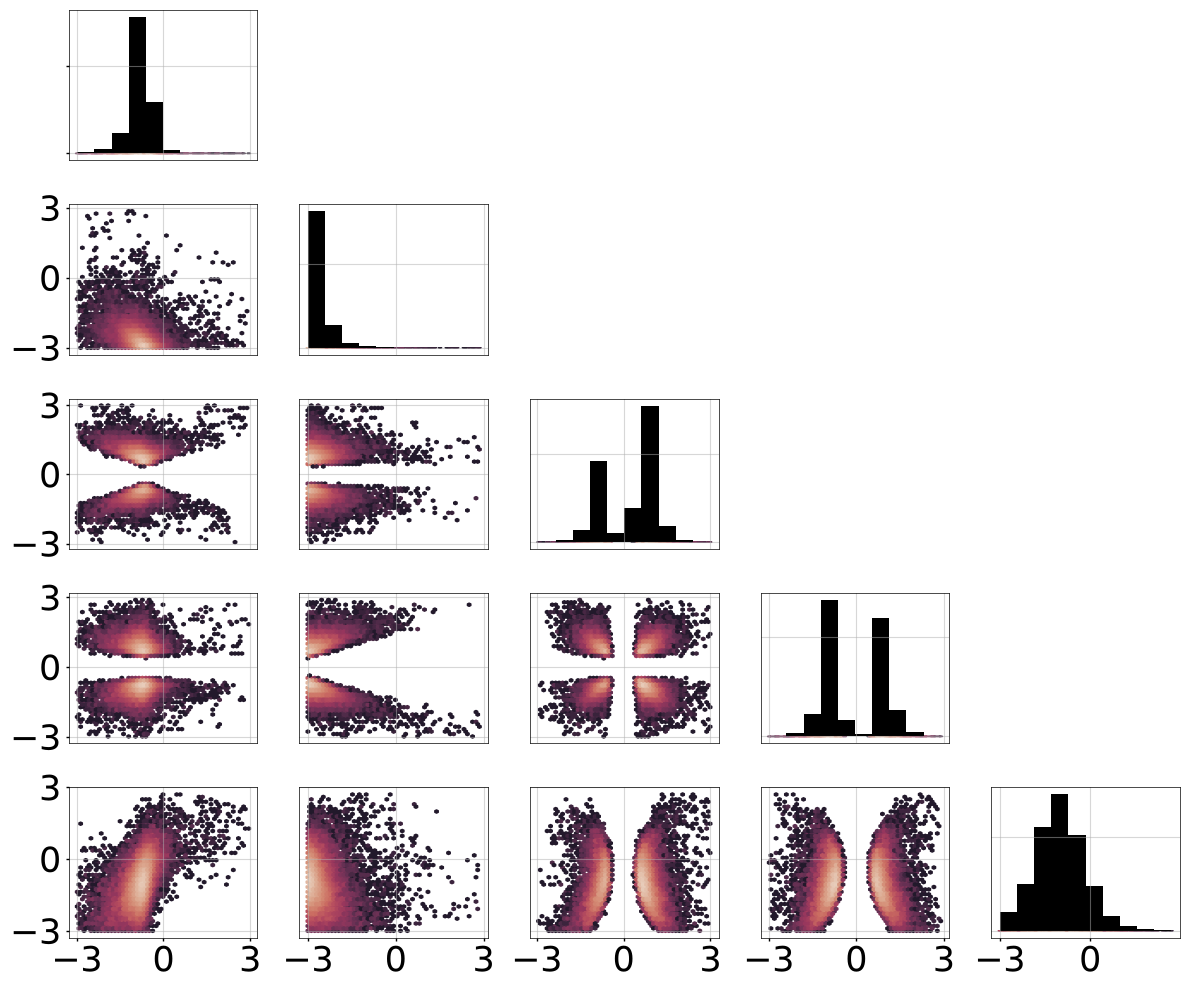

In [11]:
plot_posteriors(slice_samples.reshape(-1, 5))
plt.tight_layout()
plt.show()

### SNLE

Next, we use surjective neural likelihood estimation to compute a posterior distribution.

In [12]:
from sbijax import snle, run_sequential
from sbijax.nn import make_maf

In [13]:
n_dim_data = 8
n_layer_dimensions, hidden_sizes = (8, 8, 5, 5, 5), (64, 64)
neural_network = make_maf(
    n_dim_data, 
    n_layer_dimensions=n_layer_dimensions,
    hidden_sizes=hidden_sizes
)

prior = prior_fn()
model_snle = snle(prior, neural_network)

In [14]:
snle_params, info = run_sequential(
    jr.PRNGKey(1),
    model_snle,
    prior,
    simulator_fn,
    y_obs,
    n_rounds=15,
    n_simulations_per_round=1_000,
)

 34%|█████████                  | 335/1000 [07:52<15:38,  1.41s/it]


In [15]:
snle_samples, _ = model_snle.sample(
    jr.PRNGKey(5), snle_params, y_obs, n_samples=5_000, n_warmup=2_500, n_chains=10
)


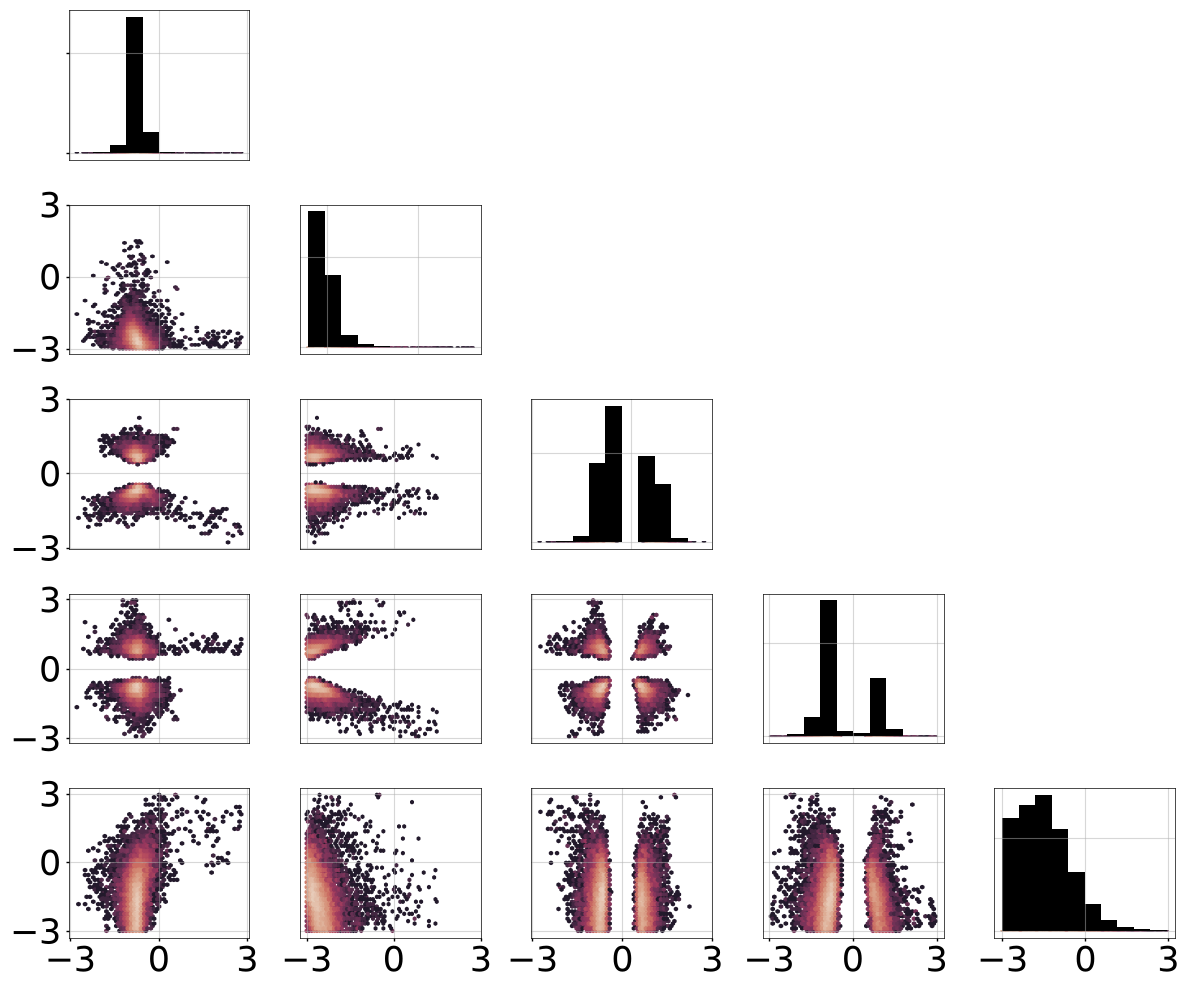

In [16]:
plot_posteriors(
    snle_samples["theta"].reshape(-1, 5),
)
plt.tight_layout()
plt.show()


### FMPE

As a comparison, we use flow matching posterior estimation.

In [17]:
from sbijax import fmpe, simulate
from sbijax.nn import make_cnf

In [18]:
n_dim_theta = 5
n_layers, hidden_size = 5, 128
neural_network = make_cnf(n_dim_theta, n_layers, hidden_size)

model_fmpe = fmpe(prior, neural_network)

In [19]:
data = simulate(
    jr.PRNGKey(1),
    prior,
    simulator_fn,
    n=20_000,
)
fmpe_params, info = model_fmpe.fit(
    jr.PRNGKey(2),
    data,
    optimizer=optax.adam(0.001),
    n_early_stopping_delta=0.00001,
    n_early_stopping_patience=30
)

  6%|█▋                          | 62/1000 [01:20<20:12,  1.29s/it]


In [20]:
fmpe_samples, _ = model_fmpe.sample(
    jr.PRNGKey(5), fmpe_params, y_obs, n_samples=25_000
)


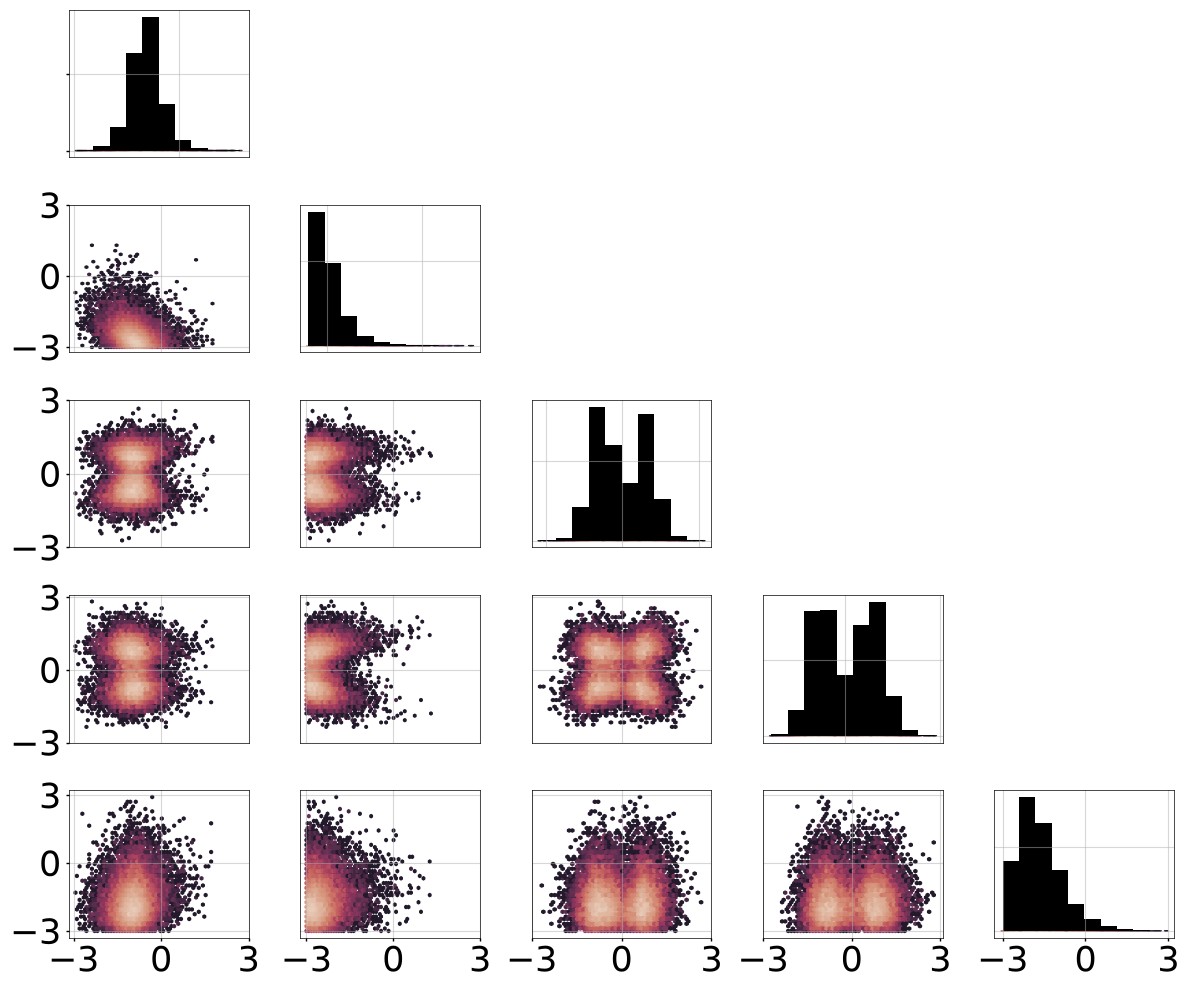

In [21]:
plot_posteriors(
    fmpe_samples["theta"].reshape(-1, 5),
)
plt.tight_layout()
plt.show()


### SMC-ABC

Finally, we evaluate SMC-ABC using neural sufficient statistics.

In [22]:
from sbijax import nass, smcabc, simulate
from sbijax.nn import make_nass_net

In [23]:
n_embedding_dim, hidden_sizes = 5, (64, 64)
neural_network = make_nass_net(n_embedding_dim, hidden_sizes)

model_nass = nass(neural_network)

data = simulate(jr.PRNGKey(1), prior, simulator_fn, n=20_000)
params_nass, _ = model_nass.fit(jr.PRNGKey(2), data, n_early_stopping_patience=25)

 22%|██████                     | 225/1000 [03:22<11:38,  1.11it/s]


In [24]:
def summary_fn(y):
    s = model_nass.summarize(params_nass, y)
    return s

def distance_fn(y_simulated, y_observed):
    diff = y_simulated - y_observed
    dist = jax.vmap(lambda el: jnp.linalg.norm(el))(diff)
    return dist

In [25]:
model_smc = smcabc(prior, simulator_fn, summary_fn, distance_fn)

smc_samples, _ = model_smc.sample(
    jr.PRNGKey(5),
    y_obs,
    n_rounds=10,
    n_particles=5_000,
    eps_step=0.825,
    ess_min=2_000
)

NameError: name 'model_smc' is not defined

In [ ]:
plot_posteriors(
    smc_samples["theta"].reshape(-1, 5),
)
plt.tight_layout()
plt.show()


## Session info

In [ ]:
import session_info

session_info.show(html=False)